# The structure of seven datasets

Seven bivariate datasets share (approximately) the same marginal moments and the same near-zero linear correlation, yet differ sharply in their dependence structure. The point of the exercise is that *correlation alone* is a poor summary of joint behavior — it can hide tail dependence, nonlinearity, and clustering that matter for portfolio and risk decisions. We compute the Pearson correlation for each pair and then look at the scatterplots.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the seven datasets

The CSV is laid out as seven $(X, Y)$ pairs in adjacent columns, separated by a blank spacer column.

In [2]:
csv_data = pd.read_csv('0_seven_datasets.csv', skiprows=1)

dataset_cols = {
    "Dataset One":   (0, 1),
    "Dataset Two":   (3, 4),
    "Dataset Three": (6, 7),
    "Dataset Four":  (9, 10),
    "Dataset Five":  (12, 13),
    "Dataset Six":   (15, 16),
    "Dataset Seven": (18, 19),
}

datasets = {
    name: csv_data.iloc[:, [x, y]].dropna().astype(float).set_axis(['X', 'Y'], axis=1)
    for name, (x, y) in dataset_cols.items()
}

## Pearson correlations

All seven correlations are close to zero.

In [3]:
correlations = {name: df['X'].corr(df['Y']) for name, df in datasets.items()}

correlation_table = pd.DataFrame(
    correlations.items(), columns=['Dataset', 'Correlation']
)
print(correlation_table.to_string(index=False))

      Dataset  Correlation
  Dataset One    -0.032461
  Dataset Two    -0.005160
Dataset Three    -0.027267
 Dataset Four    -0.020998
 Dataset Five    -0.017435
  Dataset Six     0.075651
Dataset Seven    -0.029710


## Scatterplots

The scatterplots tell a very different story than the correlations do.

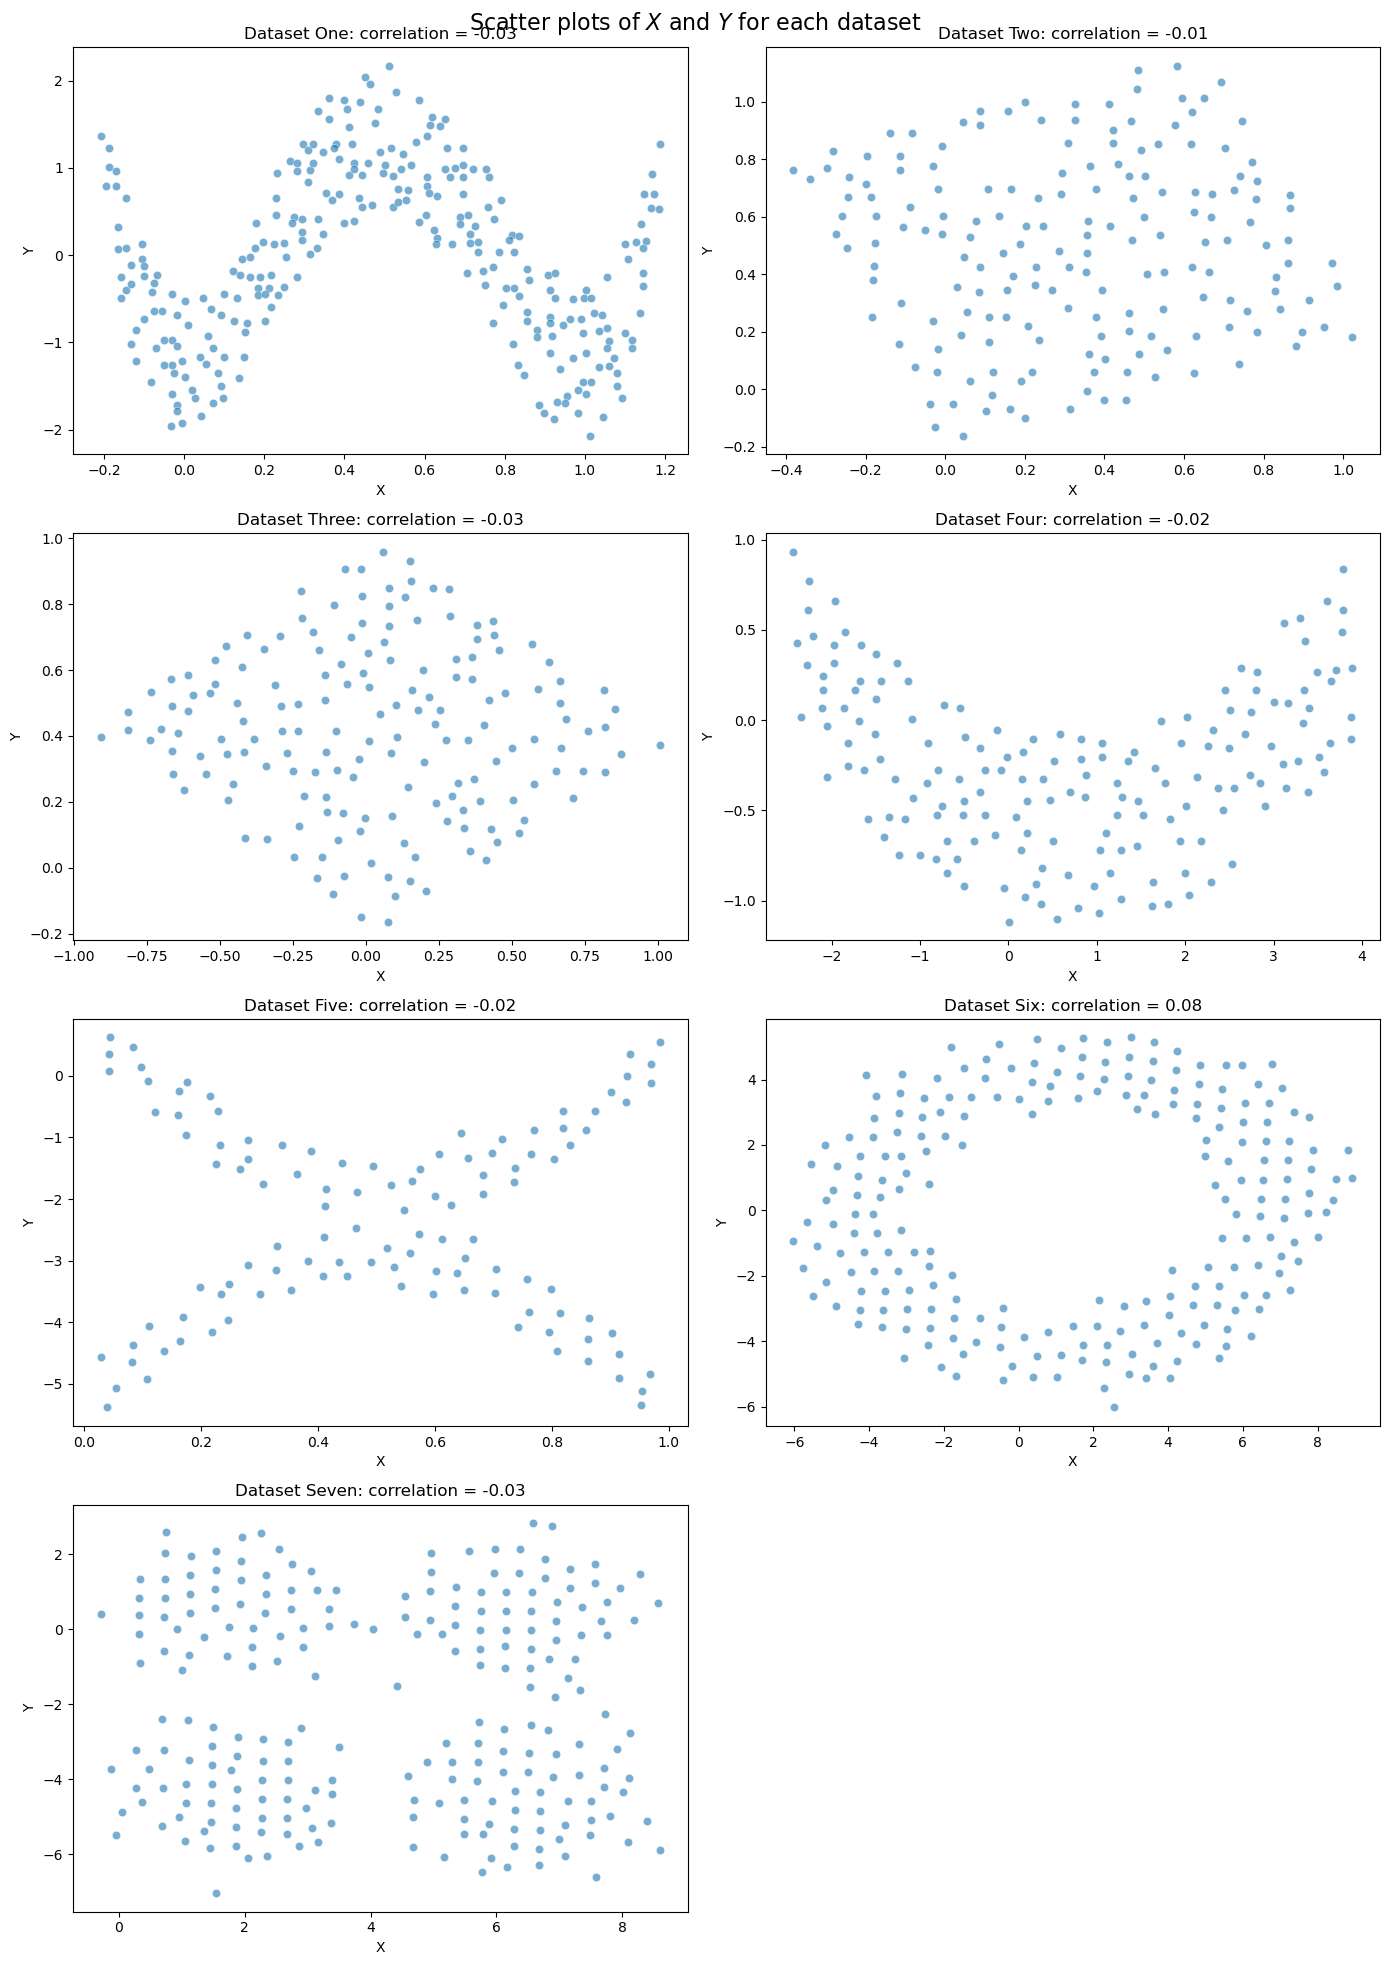

In [4]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20))
axes = axes.flatten()

for ax, (name, df) in zip(axes, datasets.items()):
    sns.scatterplot(x='X', y='Y', data=df, ax=ax, alpha=0.6)
    ax.set_title(f'{name}: correlation = {correlations[name]:.2f}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

axes[-1].set_visible(False)

fig.suptitle("Scatter plots of $X$ and $Y$ for each dataset", fontsize=16)
fig.tight_layout()
plt.show()

## Takeaway

Linear correlation summarizes one slice of the joint distribution. Two random variables can be uncorrelated and still be strongly dependent — through tails, clusters, or nonlinear structure. Modeling the dependence directly (e.g. with a copula) is what lets us capture the features that linear correlation throws away.